In [2]:
import xarray as xr
import numpy as np
import pandas as pd


from cosipy.postprocessing import cosiplot

B16_test_output = xr.open_dataset("data/output/B16_output_test_20000402-20191010.nc")
B16_aws = pd.read_csv("data/input/Bruarjokull/B16_merged_2001_2020.csv")
B16_aws['TIMESTAMP'] = pd.to_datetime(B16_aws['TIMESTAMP'])

## Testpiece

There are input files for the AWS on Bruarjokull ready to use in the data directory. Also configuration and constants files that are calibrated using the mass balance at each AWS. Using this you can run cosipy. 

For example the B16 station you can just run the following command:
```bash
 python COSIPY.py -c config_B16.toml -x constants_B16.toml
```
The output should be found in the directory /data/output and be similar to the test output file B16_output_test_20000402-20191010.nc

To see if everything worked correctly you can compare your output file to a test output file using some of the functions in the cosiplot module.

```bash
 cosiplot.compare_outputs(
 dataset1=xr.open_dataset("data/output/B16_output_20000402-20191010.nc"), 
 dataset2=B16_test_output, 
 variable_name="TOTALHEIGHT", 
 start_year=2003, end_year=2019)
```

This should just give you a brownish plot. If there are 2 different lines in the plot or just a blue one something went wrong.

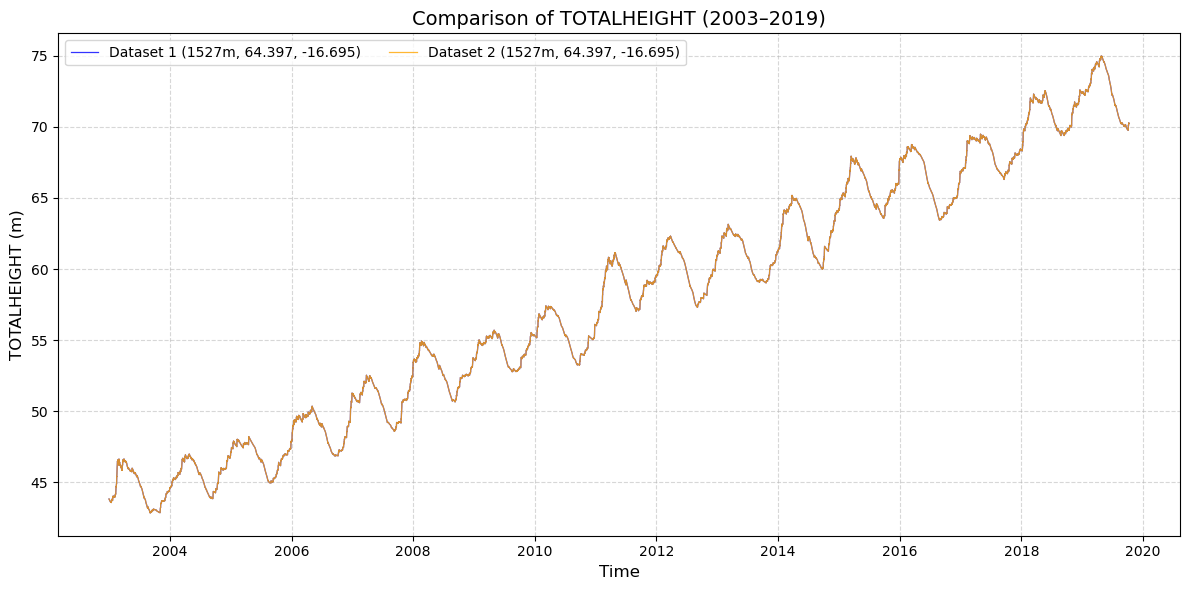

In [4]:
cosiplot.compare_outputs(
 dataset1=xr.open_dataset("data/output/B16_output_20000402-20191010.nc"), 
 dataset2=B16_test_output, 
 variable_name="TOTALHEIGHT", 
 start_year=2003, end_year=2019
) 

You can also compare the seasonal and annual mass balance to the measured mass balances.  
```bash
result_mb = cosiplot.compare_mass_balance(
    stake_file_path="data/afh-vj/B16.txt",
    ds=B16_test_output,
    start_year=2003, end_year=2019
)
```


EVALUATION METRICS (units: m w.e.)
BW  RMSE: 0.351, Corr: 0.60, Bias: 0.040
BS  RMSE: 0.382, Corr: 0.67, Bias: -0.003
BA  RMSE: 0.495, Corr: 0.72, Bias: 0.039


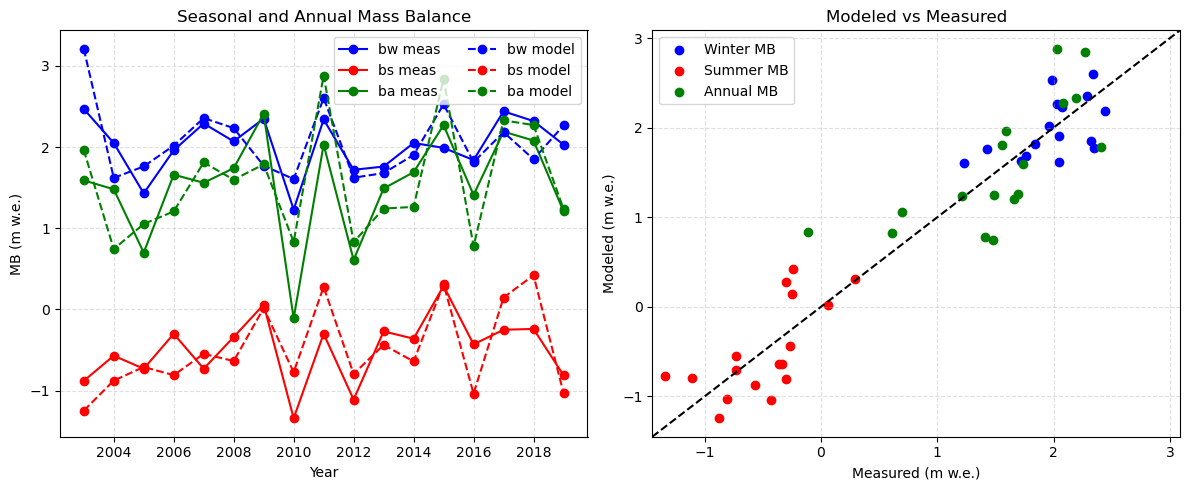

In [53]:
result_mb = cosiplot.compare_mass_balance(
    stake_file_path="data/afh-vj/B16.txt",
    ds=B16_test_output,
    start_year=2003, end_year=2019
)

Because the 2 dimensional datasets get quite large, I only put up 1D datasets to github.

If you want to do 2D model runs anyway you can run these 3 commands in succession:

```bash
 python -m cosipy.utilities.createStatic.create_static_file
```
```bash
 python -m cosipy.utilities.aws2cosipy.aws2cosipy     -i ./data/input/Bruarjokull/B13_merged_2001_2020.csv     -o ./data/input/Bruarjokull/B13_full_glacier_2001_2020.nc     -s ./data/static/Bruarjokull_static_test.nc     -b 20010101 -e 20201231
```
```bash
 python COSIPY.py -c config.toml -x constants_B13.toml
```
all the configuration files are already set up in a way that this should work, keep in mind that this is a bit memory intensive (~190gb RAM).
If you want to decrease memory usage the easiest way is to increase aggregate_degree in the utilities_config file or change the timespan in the config file. 

